# Leakage Check + Harmonisasi Label (Fase 4–5)

Input: `master_dedup_flags.csv` dan `audit_near_dup_pairs.csv` dari notebook `01_audit_dedup`.

- **Fase 4**: bentuk *grup* citra yang wajib berada di split yang sama (duplikat + `lesion_id` yang sama), dan laporkan bukti leakage.
- **Fase 5**: ubah label asli ke biner (benign/malignant) dan 3 kelas (NV/MEL/BKL) memakai mapping dari rencana riset. Label asli tidak diubah, hanya ditambah kolom baru.

Tidak ada splitting, preprocessing, Spark, atau training. Citra yang tidak dipakai **ditandai alasannya**, tidak dihapus.

## 0. Konfigurasi dan mapping label (dari rencana riset)

In [1]:
import os, json
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.width", 200, "display.max_columns", 50, "display.max_rows", 100)
IN = Path(os.environ.get("IN_DIR", "/kaggle/working/audit_dedup"))
OUT = Path(os.environ.get("OUT_DIR", "/kaggle/working/leakage_labels")); OUT.mkdir(parents=True, exist_ok=True)

# label asli (huruf kecil) -> kelas rencana. Kelas di luar tabel ini (mis. UNK) = tidak terpetakan.
# CATATAN: "ak" (nama ISIC 2019 untuk actinic keratosis) diperlakukan sama dengan AKIEC. Itu asumsi; ubah di sini bila tidak setuju.
CLASS_OF = {"nv": "NV", "nevus": "NV", "mel": "MEL", "melanoma": "MEL", "bkl": "BKL", "seborrheic_keratosis": "BKL", "vasc": "VASC",
            "df": "DF", "bcc": "BCC", "akiec": "AKIEC", "ak": "AKIEC", "scc": "SCC"}
BINARY = {"NV": 0, "BKL": 0, "VASC": 0, "DF": 0, "MEL": 1, "BCC": 1, "AKIEC": 1, "SCC": 1}   # 0 = benign, 1 = malignant
THREE_ID = {"NV": 0, "MEL": 1, "BKL": 2}                                                 # indeks 3 kelas (irisan) sesuai catatan riset
THREE = list(THREE_ID)

## 1. Muat data

In [2]:
m = pd.read_csv(IN / "master_dedup_flags.csv", low_memory=False)
m = m[m.has_image & ~m.is_corrupt].reset_index(drop=True)          # hanya citra yang ada dan bisa dibuka
m["proposed_keep"] = m.proposed_keep.astype(bool)
near = pd.read_csv(IN / "audit_near_dup_pairs.csv")
print(f"{len(m):,} citra | kandidat near-duplicate: {len(near):,} pasangan")

47,845 citra | kandidat near-duplicate: 19,935 pasangan


## 2. Fase 5 — Harmonisasi label
Tabel di bawah adalah bukti pemetaan: label asli → kelas rencana. Baris `UNMAPPED` tidak diberi kelas dan dikeluarkan.

In [3]:
m["label_original"] = m.diagnosis_original
m["label_class"] = m.label_original.astype(str).str.lower().map(CLASS_OF)          # NaN = tidak terpetakan
m["label_binary"] = m.label_class.map(BINARY).astype("Int64")                       # 0 benign, 1 malignant
m["label_3class"] = m.label_class.where(m.label_class.isin(THREE))                  # NV / MEL / BKL, selain itu kosong
m["label_3class_id"] = m.label_3class.map(THREE_ID).astype("Int64")                 # NV=0, MEL=1, BKL=2
display(pd.crosstab([m.dataset, m.label_original], m.label_class.fillna("UNMAPPED")))

label_class                    AKIEC   BCC   BKL   DF   MEL     NV  SCC  UNMAPPED  VASC
dataset  label_original                                                                
HAM10000 akiec                   370     0     0    0     0      0    0         0     0
         bcc                       0   607     0    0     0      0    0         0     0
         bkl                       0     0  1316    0     0      0    0         0     0
         df                        0     0     0  159     0      0    0         0     0
         mel                       0     0     0    0  1284      0    0         0     0
         nv                        0     0     0    0     0   7613    0         0     0
         vasc                      0     0     0    0     0      0    0         0   177
ISIC2017 melanoma                  0     0     0    0   521      0    0         0     0
         nevus                     0     0     0    0     0   1843    0         0     0
         seborrheic_keratosis      0     0   386    0     0      0    0         0     0
ISIC2019 AK                     1241     0     0    0     0      0    0         0     0
         BCC                       0  4298     0    0     0      0    0         0     0
         BKL                       0     0  3284    0     0      0    0         0     0
         DF                        0     0     0  330     0      0    0         0     0
         MEL                       0     0     0    0  5849      0    0         0     0
         NV                        0     0     0    0     0  15370    0         0     0
         SCC                       0     0     0    0     0      0  793         0     0
         UNK                       0     0     0    0     0      0    0      2047     0
         VASC                      0     0     0    0     0      0    0         0   357

## 3. Fase 4 — Grup yang wajib satu split
Dua citra digabung ke satu grup jika berada dalam **grup duplikat yang sama** (file identik / `base_id` sama) atau punya **`lesion_id` yang sama**. `lesion_id` dipropagasi lewat duplikat: jika salinan ISIC 2019 tidak punya `lesion_id` tetapi salinan HAM punya, keduanya satu grup. Gabungan dihitung pada **semua** citra (termasuk salinan yang nanti dibuang).

In [4]:
par = list(range(len(m)))
def find(x):
    while par[x] != x: par[x] = par[par[x]]; x = par[x]
    return x
for key in ["dup_group_id", "lesion_id"]:
    for idx in m.groupby(key).indices.values():          # NaN tidak ikut
        for i in idx[1:]:
            a, b = find(int(idx[0])), find(int(i))
            if a != b: par[max(a, b)] = min(a, b)
m["group_id"] = [find(i) for i in range(len(m))]
m["group_size"] = m.groupby("group_id").group_id.transform("size")
kept = m[m.proposed_keep]
gs = kept.groupby("group_id").size()
print(f"grup: {m.group_id.nunique():,} | grup dengan >1 citra terpilih: {(gs > 1).sum():,} (total {gs[gs > 1].sum():,} citra) | grup terbesar: {gs.max()} citra")
print("grup >50 citra (periksa bila ada, bisa membuat split timpang):", int((gs > 50).sum()))

grup: 21,876 | grup dengan >1 citra terpilih: 5,281 (total 16,924 citra) | grup terbesar: 31 citra
grup >50 citra (periksa bila ada, bisa membuat split timpang): 0


### Konflik label pada citra yang sama
Satu gambar (grup duplikat) dengan label berbeda antar sumber. Konflik dihitung **setelah** harmonisasi (mis. `akiec` vs `SCC` sama-sama malignant → bukan konflik biner). Untuk 3 kelas, kelas di luar NV/MEL/BKL disatukan sebagai `OTHER` sehingga `NV` vs `akiec` tetap dianggap konflik.

In [5]:
m["cls3"] = m.label_class.where(m.label_class.isin(THREE), "OTHER").where(m.label_class.notna())
m["dup_key"] = m.dup_group_id.where(m.dup_group_id.notna(), -1 - m.index.to_series())      # citra tanpa duplikat = grup sendiri
g = m.groupby("dup_key")
m["conflict_binary"] = g.label_binary.transform("nunique") > 1
m["conflict_3class"] = g.cls3.transform("nunique") > 1
cf = m[m.conflict_binary | m.conflict_3class].groupby("dup_key").agg(n=("image_id", "size"), datasets=("dataset", lambda s: " & ".join(sorted(set(s)))),
        labels=("label_original", lambda s: ",".join(sorted(set(s.astype(str))))), binary=("conflict_binary", "first"), three=("conflict_3class", "first"))
print(f"grup duplikat berkonflik: biner={int(cf.binary.sum())} | 3 kelas={int(cf.three.sum())}"); display(cf.head(15))
cf.to_csv(OUT / "audit_label_conflicts.csv")
# hanya audit (tidak mengeluarkan citra): foto berbeda dari lesi yang sama tetapi label biner berbeda
lc = m.dropna(subset=["lesion_id"]).groupby("lesion_id").label_binary.nunique()
print("lesion_id dengan label biner berbeda antar foto:", int((lc > 1).sum()), "dari", len(lc), "lesi")

grup duplikat berkonflik: biner=2 | 3 kelas=2


,n,datasets,labels,binary,three
dup_key,,,,,
14312.0,2,ISIC2019,"MEL,NV",True,True
14314.0,2,ISIC2019,"MEL,NV",True,True


lesion_id dengan label biner berbeda antar foto: 0 dari 13069 lesi


## 4. Status tiap citra (audit trail)
Urutan alasan: bukan salinan terpilih → label tidak terpetakan → (3 kelas: di luar NV/MEL/BKL) → konflik label. Citra `VALID` yang dipakai tiap tugas.

In [6]:
m["status_binary"] = np.select([~m.proposed_keep, m.label_class.isna(), m.conflict_binary], ["DUPLICATE_NOT_KEPT", "UNMAPPED_LABEL", "LABEL_CONFLICT"], "VALID")
m["status_3class"] = np.select([~m.proposed_keep, m.label_class.isna(), ~m.label_class.isin(THREE), m.conflict_3class],
                               ["DUPLICATE_NOT_KEPT", "UNMAPPED_LABEL", "OUT_OF_SCOPE_CLASS", "LABEL_CONFLICT"], "VALID")
st = pd.concat({"biner": m.status_binary.value_counts(), "3 kelas": m.status_3class.value_counts()}, axis=1).fillna(0).astype(int); display(st)
display(m[m.status_binary == "UNMAPPED_LABEL"].groupby(["dataset", "source_split", "label_original"]).size().rename("n"))
for name, col, lab in [("biner", "status_binary", "label_binary"), ("3 kelas", "status_3class", "label_3class")]:
    v = m[m[col] == "VALID"]; print(f"\n== {name}: {len(v):,} citra valid"); display(pd.crosstab(v.dataset, v[lab], margins=True))

,biner,3 kelas
VALID,31470,24466
DUPLICATE_NOT_KEPT,14326,14326
UNMAPPED_LABEL,2047,2047
LABEL_CONFLICT,2,2
OUT_OF_SCOPE_CLASS,0,7004


dataset   source_split  label_original
ISIC2019  test          UNK               2047
Name: n, dtype: int64


== biner: 31,470 citra valid


label_binary,0,1,All
dataset,,,
HAM10000,9263,2261,11524
ISIC2019,10051,9895,19946
All,19314,12156,31470



== 3 kelas: 24,466 citra valid


label_3class,BKL,MEL,NV,All
dataset,,,,
HAM10000,1316,1284,7611,10211
ISIC2019,1954,4555,7746,14255
All,3270,5839,15357,24466


## 5. Bukti leakage
Istilah: **verified clean** = diperiksa dan bersih; **potential overlap** = ada kandidat yang belum bisa dipastikan; **not verifiable** = tidak ada identifier untuk memeriksa.

In [7]:
v = m[m.status_binary == "VALID"]
ng = v.assign(has_lid=v.lesion_id.notna() | v.dup_group_id.notna())
print("file identik / base_id sama di antara citra valid :", "verified clean" if not v.duplicated("sha256").any() and not v.duplicated(["base_id"]).any() else "ADA SISA")
print("lesion_id sama                                     : ditangani lewat group_id (wajib satu split)")
print("tanpa lesion_id dan tanpa duplikat (not verifiable):", int((~ng.has_lid).sum()), "citra"); display(ng[~ng.has_lid].groupby("dataset").size().rename("n"))
gid = m.set_index("image_path").group_id; a, b = near.image_path_1.map(gid), near.image_path_2.map(gid)
cand = near[(~near.exact) & (~near.same_id) & a.notna() & b.notna() & (a != b)]
kp = m.set_index("image_path").status_binary.eq("VALID"); cand = cand[cand.image_path_1.map(kp).fillna(False) & cand.image_path_2.map(kp).fillna(False)]
print(f"kandidat near-duplicate antar grup berbeda (potential overlap): {len(cand):,} pasangan | pHash<=2: {int((cand.phash_dist <= 2).sum()):,}")
cand.to_csv(OUT / "audit_near_candidates_cross_group.csv", index=False)

def check_split_leakage(df, split_col="split"):
    """Panggil setelah split (Fase 6). Tiga angka pertama harus 0; near_pairs_crossing = potential overlap."""
    s = df.set_index("image_path")[split_col]; x, y = near.image_path_1.map(s), near.image_path_2.map(s)
    ok = (~near.exact) & (~near.same_id) & x.notna() & y.notna()
    return {"group_id": int((df.groupby("group_id")[split_col].nunique() > 1).sum()),
            "lesion_id": int((df.dropna(subset=["lesion_id"]).groupby("lesion_id")[split_col].nunique() > 1).sum()),
            "sha256": int((df.groupby("sha256")[split_col].nunique() > 1).sum()),
            "near_pairs_crossing": int((ok & (x != y)).sum())}

file identik / base_id sama di antara citra valid : verified clean
lesion_id sama                                     : ditangani lewat group_id (wajib satu split)
tanpa lesion_id dan tanpa duplikat (not verifiable): 4838 citra


dataset
ISIC2019    4838
Name: n, dtype: int64

kandidat near-duplicate antar grup berbeda (potential overlap): 2,102 pasangan | pHash<=2: 278


## 6. Simpan

irisan 3 kelas (24,466) adalah subset dari biner (31,470): OK


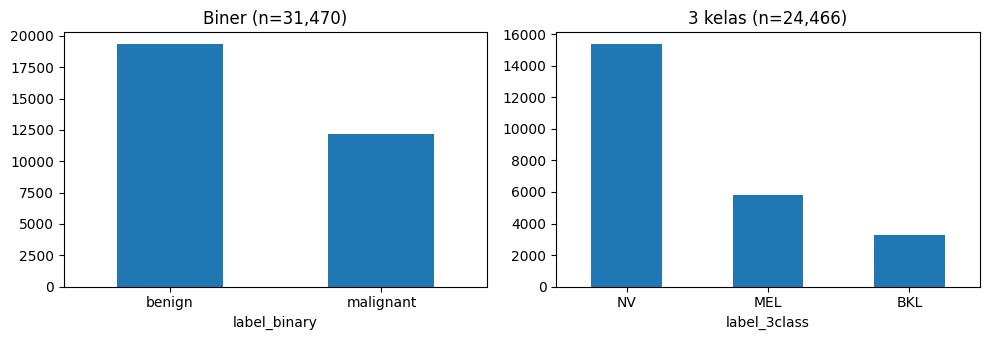

{
  "images_considered": 47845,
  "binary_valid": 31470,
  "binary_benign": 19314,
  "binary_malignant": 12156,
  "three_class_valid": 24466,
  "three_class_counts": {
    "NV": 15357,
    "MEL": 5839,
    "BKL": 3270
  },
  "status_binary": {
    "VALID": 31470,
    "DUPLICATE_NOT_KEPT": 14326,
    "UNMAPPED_LABEL": 2047,
    "LABEL_CONFLICT": 2
  },
  "status_3class": {
    "VALID": 24466,
    "DUPLICATE_NOT_KEPT": 14326,
    "OUT_OF_SCOPE_CLASS": 7004,
    "UNMAPPED_LABEL": 2047,
    "LABEL_CONFLICT": 2
  },
  "groups_valid_binary": 19828,
  "label_conflict_groups_binary": 2,
  "label_conflict_groups_3class": 2,
  "near_candidates_cross_group": 2102,
  "assumption": "ak (ISIC 2019) dianggap AKIEC"
}
Output: /kaggle/working/leakage_labels


In [8]:
cols = ["image_id", "base_id", "dataset", "source_split", "image_path", "label_original", "label_class", "label_binary", "label_3class", "label_3class_id",
        "lesion_id", "group_id", "dup_group_id", "sha256", "status_binary", "status_3class"]
m[cols].to_csv(OUT / "master_clean.csv", index=False)                                              # semua citra + status
m[m.status_binary == "VALID"][cols].to_csv(OUT / "manifest_binary.csv", index=False)               # siap untuk Fase 6 (biner)
m[m.status_3class == "VALID"][cols].to_csv(OUT / "manifest_3class.csv", index=False)               # siap untuk Fase 6 (3 kelas)
st.to_csv(OUT / "audit_status_counts.csv")
vb, v3 = m[m.status_binary == "VALID"], m[m.status_3class == "VALID"]
assert set(v3.image_path) <= set(vb.image_path), "citra irisan harus subset dari biner"; print(f"irisan 3 kelas ({len(v3):,}) adalah subset dari biner ({len(vb):,}): OK")
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
vb.label_binary.map({0: "benign", 1: "malignant"}).value_counts().plot.bar(ax=ax[0], title=f"Biner (n={len(vb):,})", rot=0)
v3.label_3class.value_counts().plot.bar(ax=ax[1], title=f"3 kelas (n={len(v3):,})", rot=0); fig.tight_layout(); fig.savefig(OUT / "class_distribution.png", dpi=130); plt.show()
summary = {"images_considered": len(m), "binary_valid": len(vb), "binary_benign": int((vb.label_binary == 0).sum()), "binary_malignant": int((vb.label_binary == 1).sum()),
           "three_class_valid": len(v3), "three_class_counts": v3.label_3class.value_counts().to_dict(), "status_binary": m.status_binary.value_counts().to_dict(),
           "status_3class": m.status_3class.value_counts().to_dict(), "groups_valid_binary": int(vb.group_id.nunique()),
           "label_conflict_groups_binary": int(cf.binary.sum()), "label_conflict_groups_3class": int(cf.three.sum()),
           "near_candidates_cross_group": len(cand), "assumption": "ak (ISIC 2019) dianggap AKIEC"}
json.dump(summary, open(OUT / "leakage_labels_summary.json", "w"), indent=2); print(json.dumps(summary, indent=2)); print("Output:", OUT)